<a href="https://colab.research.google.com/github/XTruong1511/TH_DeepLaening/blob/main/TH_Deep_B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân Tích Dữ Liệu Titanic & Dự Đoán Sống Sót


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Tải và Làm sạch dữ liệu
url = 'https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/titanic_disaster.csv'
df = pd.read_csv(url)
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Tách X và y
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

# 2. Chia dữ liệu (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Kích thước dữ liệu: Train({len(X_train)}), Val({len(X_val)}), Test({len(X_test)})")
display(df_clean.head())

Kích thước dữ liệu: Train(623), Val(134), Test(134)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### Tiền xử lý dữ liệu tự động


In [54]:
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# Pipeline cho dữ liệu số
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

# Pipeline cho dữ liệu phân loại
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, numeric_features),
    ('cat', cat_pipe, categorical_features)
])

# fit_transform trên Train và transform trên Val/Test
X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

### Huấn luyện và Đánh giá tổng quát


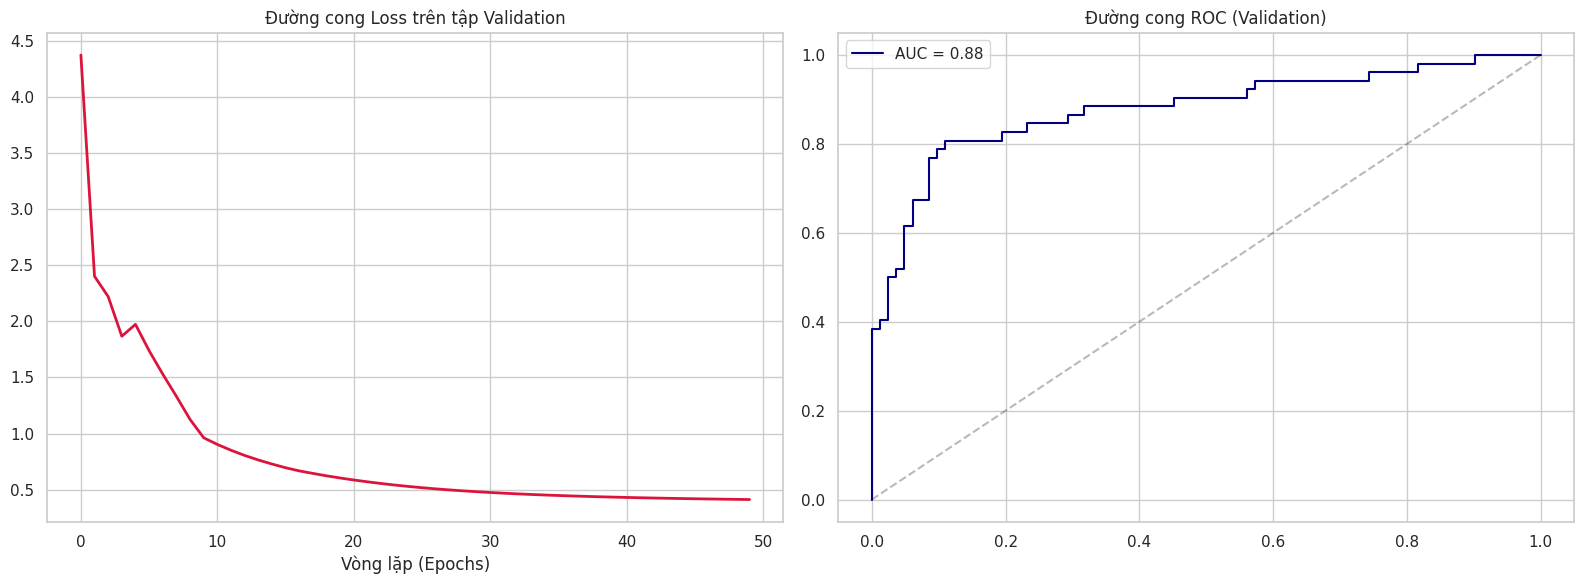

In [61]:
clf = SGDClassifier(loss='log_loss', warm_start=True, random_state=42)
val_losses = []

for i in range(50):
    clf.partial_fit(X_train_p, y_train, classes=np.unique(y))
    val_losses.append(log_loss(y_val, clf.predict_proba(X_val_p)))

# Trực quan hóa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Loss curve
ax1.plot(val_losses, color='crimson', lw=2)
ax1.set_title('Đường cong Loss trên tập Validation')
ax1.set_xlabel('Vòng lặp (Epochs)')

# ROC curve
y_score = clf.predict_proba(X_val_p)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_score)
ax2.plot(fpr, tpr, color='navy', label=f'AUC = {auc(fpr, tpr):.2f}')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax2.set_title('Đường cong ROC (Validation)')
ax2.legend()

plt.tight_layout()
plt.show()

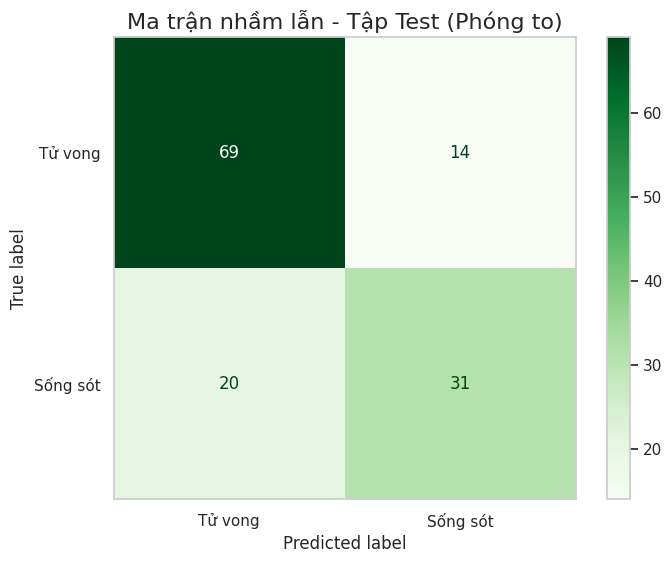

              precision    recall  f1-score   support

           0       0.78      0.83      0.80        83
           1       0.69      0.61      0.65        51

    accuracy                           0.75       134
   macro avg       0.73      0.72      0.72       134
weighted avg       0.74      0.75      0.74       134



In [63]:
y_test_pred = clf.predict(X_test_p)

fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ Confusion Matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap='Greens',
    display_labels=['Tử vong', 'Sống sót'],
    ax=ax,
    colorbar=True
)

plt.title('Ma trận nhầm lẫn - Tập Test', fontsize=16)
plt.grid(False)
plt.show()

print(classification_report(y_test, y_test_pred))

bài tập CNN

In [64]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu mẫu (MNIST)
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Chuẩn hóa dữ liệu về khoảng [0, 1]
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

print(f"Dữ liệu huấn luyện: {train_images.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dữ liệu huấn luyện: (60000, 28, 28, 1)


In [65]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.9570 - loss: 0.1402 - val_accuracy: 0.9843 - val_loss: 0.0446
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 98s 38ms/step - accuracy: 0.9856 - loss: 0.0456 - val_accuracy: 0.9881 - val_loss: 0.0374
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 28ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.9885 - val_loss: 0.0342
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9926 - loss: 0.0226 - val_accuracy: 0.9894 - val_loss: 0.0313
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.9938 - loss: 0.0187 - val_accuracy: 0.9913 - val_loss: 0.0298


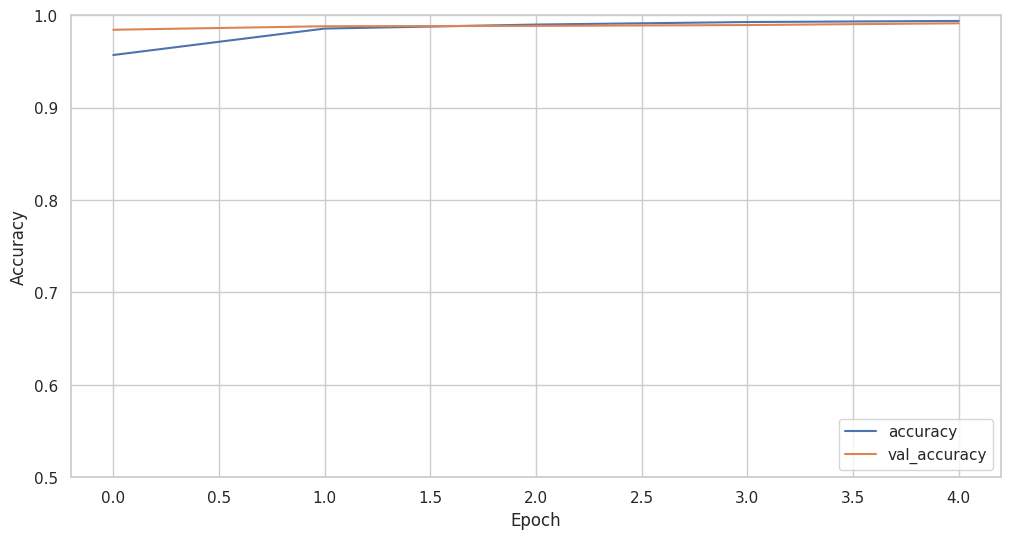

In [66]:
# 3. Huấn luyện mô hình
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

# 4. Trực quan hóa kết quả
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

chữ viết tay


In [77]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [71]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)
(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


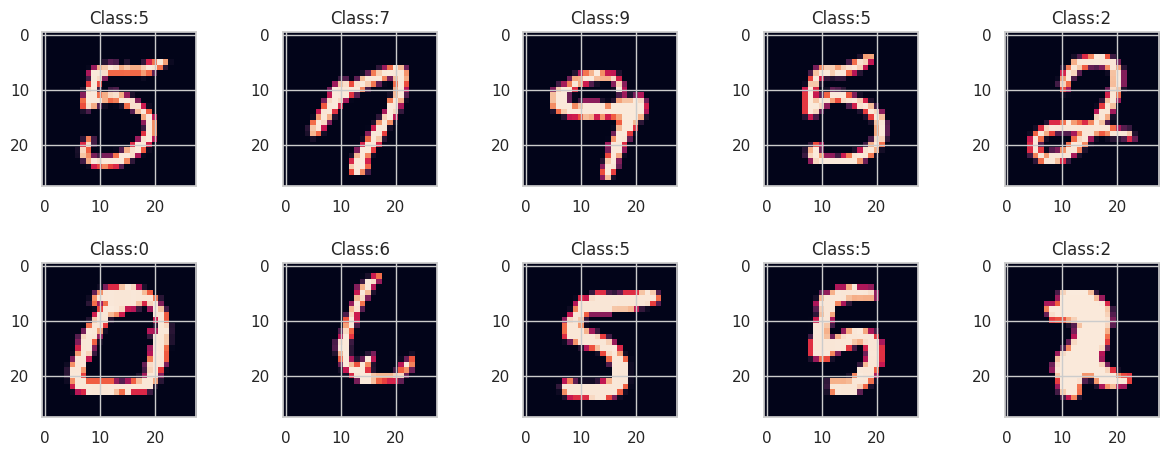

In [72]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [73]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [74]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.9105 - loss: 0.3013 - val_accuracy: 0.9739 - val_loss: 0.0903
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.9740 - loss: 0.0830 - val_accuracy: 0.9798 - val_loss: 0.0691
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9825 - loss: 0.0565 - val_accuracy: 0.9804 - val_loss: 0.0586
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9859 - loss: 0.0425 - val_accuracy: 0.9826 - val_loss: 0.0533
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9887 - loss: 0.0354 - val_accuracy: 0.9846 - val_loss: 0.0451
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9914 - loss: 0.0259 - val_accuracy: 0.9839 - val_loss: 0.0515
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9923 - loss: 0.0240 - val_accuracy: 0.9857 - val_loss: 0.0461
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9942 - loss: 0.0184 - 

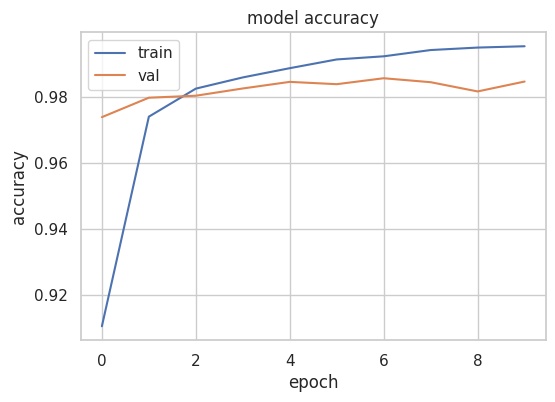

In [80]:
# 1. Biên dịch mô hình
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 2. Huấn luyện mô hình và lưu lịch sử vào biến model_fit
model_fit = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# 3. Vẽ biểu đồ độ chính xác
plt.figure(figsize=(6, 4))
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

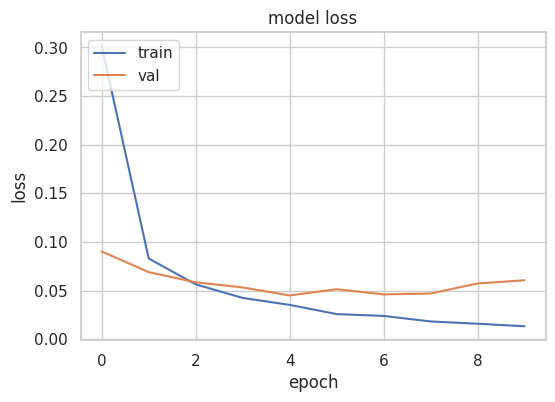

In [81]:
plt.figure(figsize=(6, 4))
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [82]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 7s - 22ms/step - accuracy: 0.9847 - loss: 0.0607
Test loss: 0.06069511920213699
Test accuracy: 0.984698474407196


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
[[5.7904367e-07 4.1898729e-06 9.9999523e-01 2.2621200e-11 2.7674281e-19
  1.9232426e-17 4.5593088e-11 1.7432108e-21 2.3664135e-10 2.3644997e-18]]
2 2


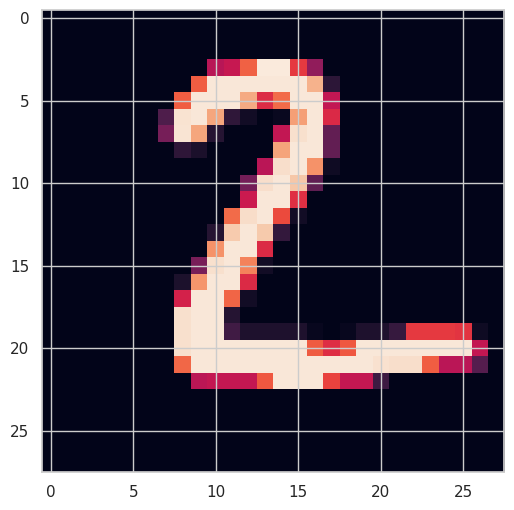

In [83]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [87]:

model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[[0.10552426 0.09831507 0.09841206 0.1069311  0.09160236 0.09282066
  0.10571232 0.10038268 0.09419461 0.10610489]]
3 1


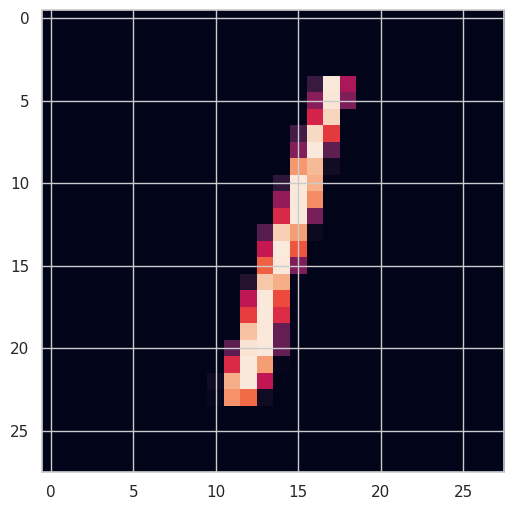

In [88]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()